## Модели прогнозирования объема убоя Овцы и козы по Жамбылской области

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### Подготовка данных и EDA

In [2]:
df = pd.read_excel("Датасет по овцы и козы с регрессорами.xlsx")
df.sample(10)

,Регион,Период,Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
1502,КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ,2023-08,696.85,3.0,32815,26.841935,194.955250
761,ГАСТАНА,2018-06,3.96,47.0,2076,18.486667,118.288273
1884,СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2017-09,747.66,17.8,387701,10.236667,113.480509
1769,ПАВЛОДАРСКАЯ ОБЛАСТЬ,2018-02,570.00,6.8,583184,-16.282143,116.234007
1214,КАРАГАНДИНСКАЯ ОБЛАСТЬ,2019-08,1510.90,22.0,1081705,19.803226,133.362435
750,ГАСТАНА,2017-07,5.12,26.3,1654,20.945161,111.576054
1928,СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2021-05,518.63,7.3,493883,18.729032,158.367994
672,ГАЛМАТЫ,2021-01,0.20,12.9,1734,-5.661290,177.401412
1385,КОСТАНАЙСКАЯ ОБЛАСТЬ,2023-11,499.96,55.2,32521,0.646667,201.440946
1147,ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2024-01,586.05,51.1,1153608,-12.048387,245.125269


In [3]:
df_zhambyl = df[df['Регион'] == 'ЖАМБЫЛСКАЯ ОБЛАСТЬ']
df_zhambyl = df_zhambyl.drop('Регион', axis = 'columns')
df_zhambyl.head()

,Период,Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
919,2015-01,1814.37,48.5,2374430,-2.306452,100.0
920,2015-02,2104.12,25.3,2492457,1.871429,100.0
921,2015-03,2251.24,36.2,2838619,3.958065,100.0
922,2015-04,2227.48,25.4,3160577,14.166667,96.8
923,2015-05,2403.42,16.4,3182406,20.106452,96.8


In [4]:
df_zhambyl = df_zhambyl.rename(columns={'Овцы и козы': 'Объем убоя: Овцы и козы'})
df_zhambyl.head()

,Период,Объем убоя: Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
919,2015-01,1814.37,48.5,2374430,-2.306452,100.0
920,2015-02,2104.12,25.3,2492457,1.871429,100.0
921,2015-03,2251.24,36.2,2838619,3.958065,100.0
922,2015-04,2227.48,25.4,3160577,14.166667,96.8
923,2015-05,2403.42,16.4,3182406,20.106452,96.8


In [5]:
df_zhambyl['Период'] = pd.to_datetime(df_zhambyl['Период'], format='%Y-%m')
df_zhambyl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 919 to 1038
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Период                   120 non-null    datetime64[ns]
 1   Объем убоя: Овцы и козы  120 non-null    float64       
 2   Осадки                   120 non-null    float64       
 3   Поголовье: овцы и козы   120 non-null    int64         
 4   Температура              120 non-null    float64       
 5   Цена: Баранина           120 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 6.6 KB


In [6]:
df_zhambyl.isna().sum()

Период                     0
Объем убоя: Овцы и козы    0
Осадки                     0
Поголовье: овцы и козы     0
Температура                0
Цена: Баранина             0
dtype: int64

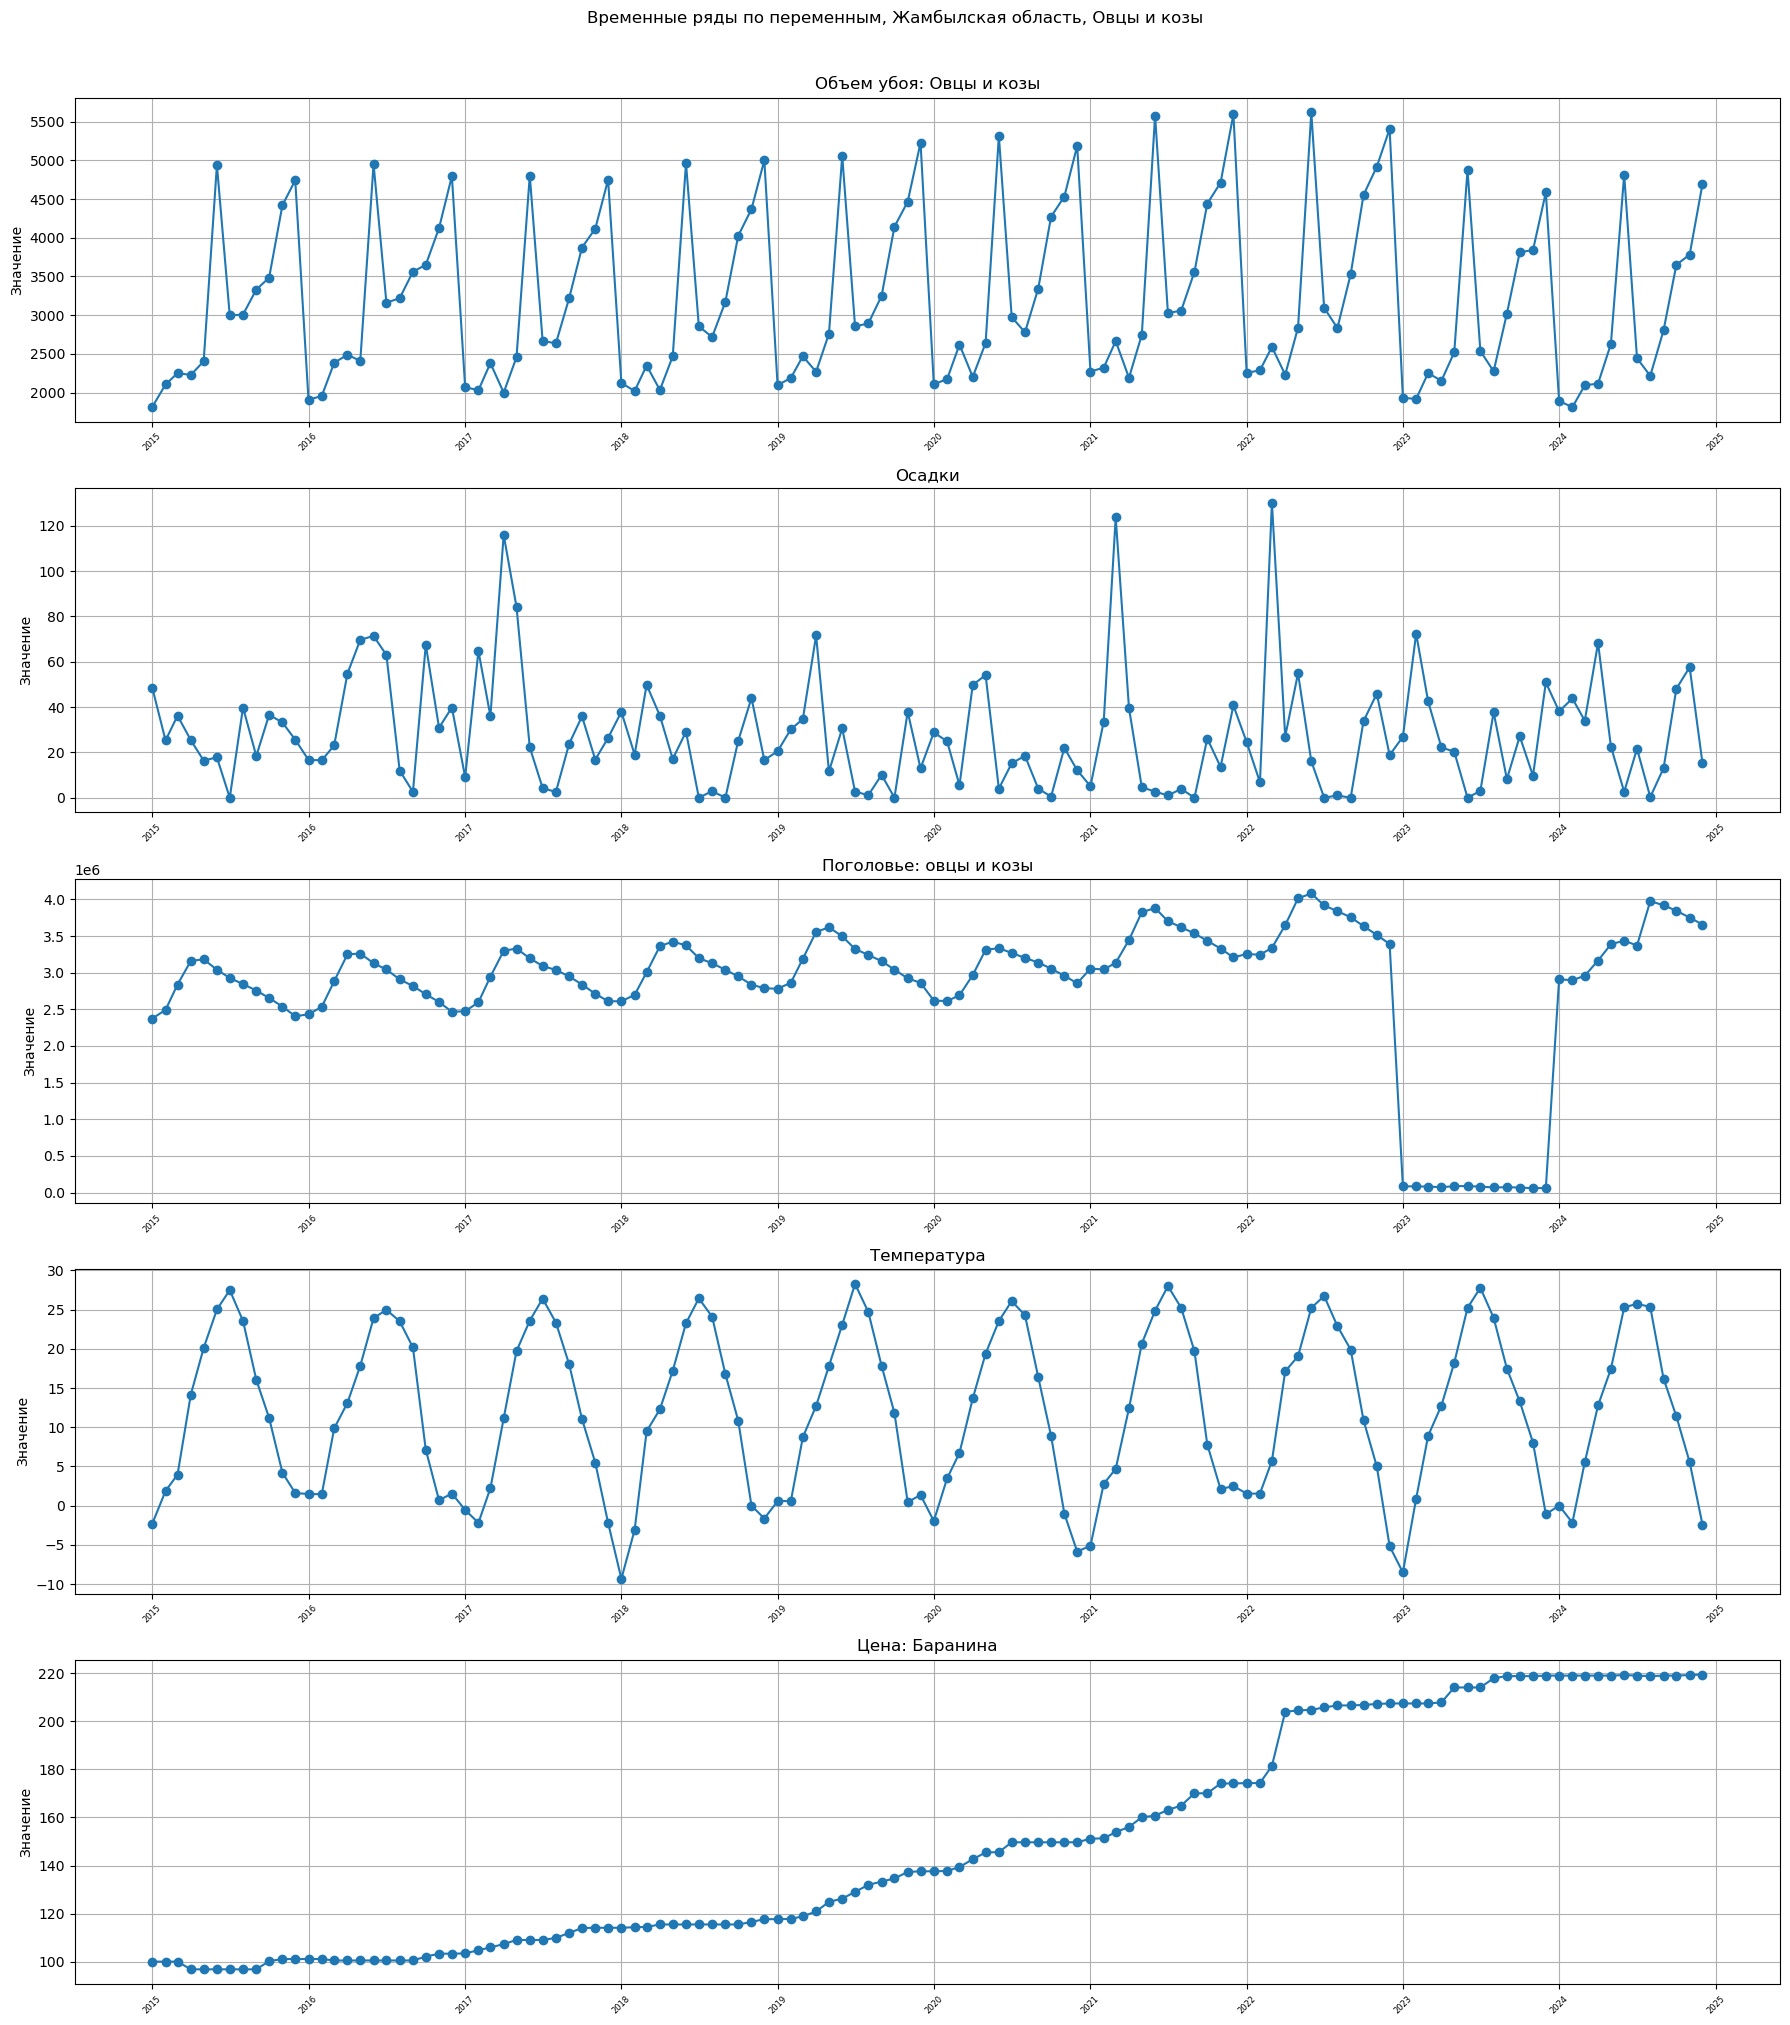

In [7]:
# Plot each variable in its own subplot
value_cols = [col for col in df_zhambyl.columns if col not in ["Период"]]

n = len(value_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(value_cols, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_zhambyl["Период"], df_zhambyl[col], marker="o")
    plt.title(f"{col}")
    plt.grid(True)
    plt.ylabel("Значение")
    plt.xticks(rotation=45, fontsize = 6)

plt.suptitle("Временные ряды по переменным, Жамбылская область, Овцы и козы", y=1.01)
plt.tight_layout()
plt.show()

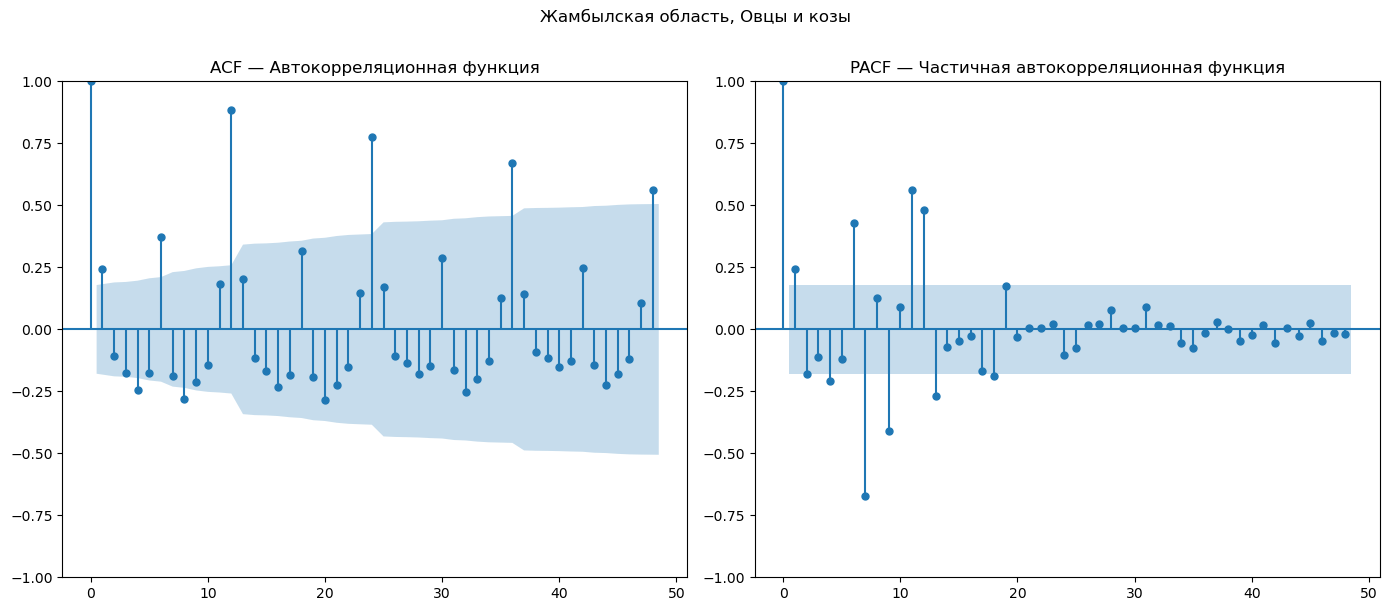

In [9]:
y = df_zhambyl["Объем убоя: Овцы и козы"].sort_index()

# Plot ACF and PACF
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_acf(y, lags=48, ax=plt.gca(), title="ACF — Автокорреляционная функция")

plt.subplot(1, 2, 2)
plot_pacf(y, lags=48, ax=plt.gca(), title="PACF — Частичная автокорреляционная функция", method="ywm")
plt.suptitle("Жамбылская область, Овцы и козы", y=1.01)

plt.tight_layout()
plt.show()

Графики автокорреляционной и частичной автокорреляционной функций указывают на **сильную взаимосвязь показателей текущего месяца со значениями следующего месяца** и на возможную **годовую сезонность** (пики на +12, +24, +36 и +48 месяцев). 

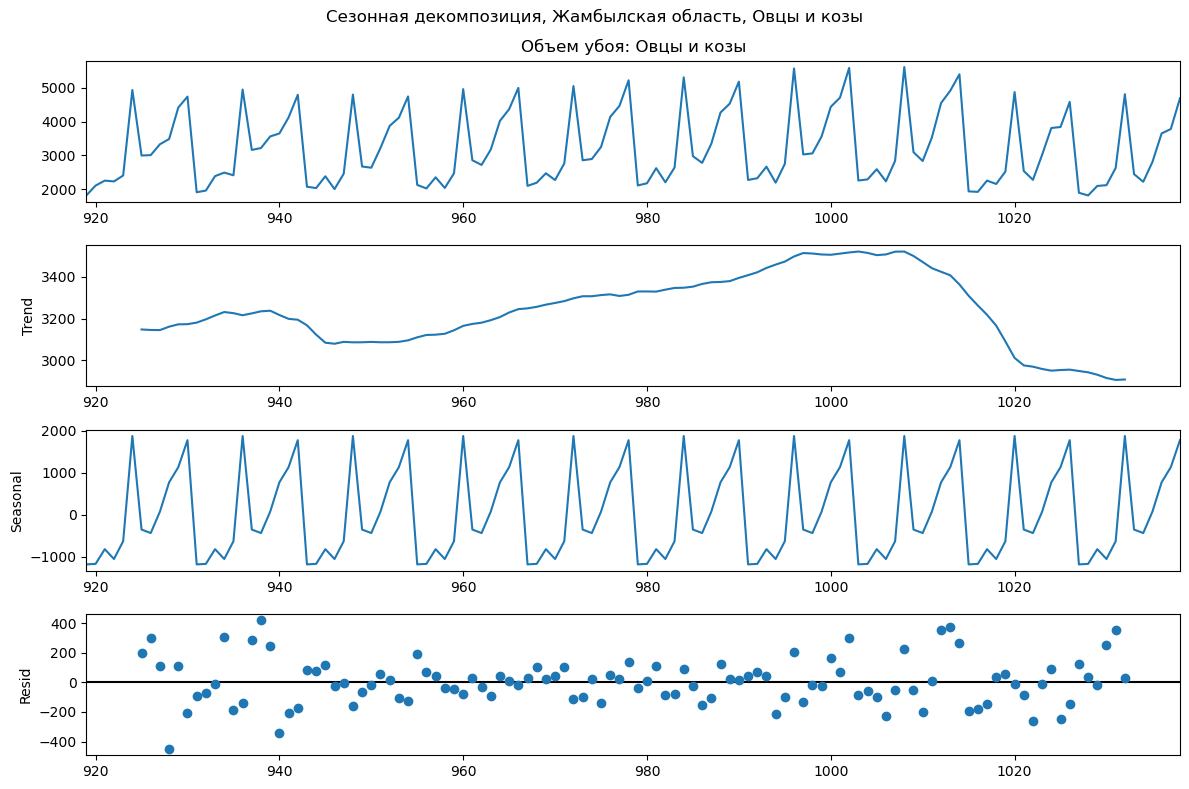

In [10]:
# Perform decomposition (period=12 for monthly data)
decomposition = seasonal_decompose(df_zhambyl["Объем убоя: Овцы и козы"], model="additive", period=12)

# Plot with larger figure size
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Сезонная декомпозиция, Жамбылская область, Овцы и козы", fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
# Run ADF test
result = adfuller(df_zhambyl["Объем убоя: Овцы и козы"])

# Display results
print("📊 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

# Interpretation
if result[1] < 0.05:
    print("✅ The series is likely **stationary** (reject H₀).")
else:
    print("❌ The series is likely **non-stationary** (fail to reject H₀).")


📊 Augmented Dickey-Fuller Test Results:
ADF Statistic: -0.9622
p-value: 0.7668
Critical Value (1%): -3.4930
Critical Value (5%): -2.8890
Critical Value (10%): -2.5814
❌ The series is likely **non-stationary** (fail to reject H₀).


Результаты теста ADF указывают на **нестационарность** временного ряда.

In [12]:
df_zhambyl

,Период,Объем убоя: Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
919,2015-01-01,1814.37,48.5,2374430,-2.306452,100.000000
920,2015-02-01,2104.12,25.3,2492457,1.871429,100.000000
921,2015-03-01,2251.24,36.2,2838619,3.958065,100.000000
922,2015-04-01,2227.48,25.4,3160577,14.166667,96.800000
923,2015-05-01,2403.42,16.4,3182406,20.106452,96.800000
...,...,...,...,...,...,...
1034,2024-08-01,2216.19,0.3,3976173,25.345161,218.835824
1035,2024-09-01,2803.71,13.0,3919543,16.213333,219.054660
1036,2024-10-01,3650.97,48.1,3844897,11.387097,219.054660
1037,2024-11-01,3782.45,57.6,3751384,5.546667,219.273715


In [13]:
# Создание лагов t-1 до t-6 для переменных
for lag in range(1, 7):
    df_zhambyl[f"Овцы и козы_t-{lag}"] = df_zhambyl["Объем убоя: Овцы и козы"].shift(lag)
    df_zhambyl[f"Температура_t-{lag}"] = df_zhambyl["Температура"].shift(lag)
    df_zhambyl[f"Осадки_t-{lag}"] = df_zhambyl["Осадки"].shift(lag)
    df_zhambyl[f"Поголовье: овцы и козы_t-{lag}"] = df_zhambyl["Поголовье: овцы и козы"].shift(lag)
    df_zhambyl[f"Цена: Баранина_t-{lag}"] = df_zhambyl["Цена: Баранина"].shift(lag)

df_zhambyl_full = df_zhambyl[["Период", "Объем убоя: Овцы и козы", 
                            "Овцы и козы_t-1", "Овцы и козы_t-2", "Овцы и козы_t-3", "Овцы и козы_t-4", "Овцы и козы_t-5", "Овцы и козы_t-6",
                            "Температура", "Температура_t-1", "Температура_t-2", "Температура_t-3", "Температура_t-4", "Температура_t-5", "Температура_t-6",
                            "Осадки", "Осадки_t-1", "Осадки_t-2", "Осадки_t-3", "Осадки_t-4", "Осадки_t-5", "Осадки_t-6",
                            "Поголовье: овцы и козы", "Поголовье: овцы и козы_t-1", "Поголовье: овцы и козы_t-2", "Поголовье: овцы и козы_t-3", "Поголовье: овцы и козы_t-4", "Поголовье: овцы и козы_t-5", "Поголовье: овцы и козы_t-6",
                            "Цена: Баранина", "Цена: Баранина_t-1", "Цена: Баранина_t-2", "Цена: Баранина_t-3", "Цена: Баранина_t-4", "Цена: Баранина_t-5", "Цена: Баранина_t-6"]]
df_zhambyl_full

,Период,Объем убоя: Овцы и козы,Овцы и козы_t-1,Овцы и козы_t-2,Овцы и козы_t-3,Овцы и козы_t-4,Овцы и козы_t-5,Овцы и козы_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-3,Температура_t-4,Температура_t-5,Температура_t-6,Осадки,Осадки_t-1,Осадки_t-2,Осадки_t-3,Осадки_t-4,Осадки_t-5,Осадки_t-6,Поголовье: овцы и козы,Поголовье: овцы и козы_t-1,Поголовье: овцы и козы_t-2,Поголовье: овцы и козы_t-3,Поголовье: овцы и козы_t-4,Поголовье: овцы и козы_t-5,Поголовье: овцы и козы_t-6,Цена: Баранина,Цена: Баранина_t-1,Цена: Баранина_t-2,Цена: Баранина_t-3,Цена: Баранина_t-4,Цена: Баранина_t-5,Цена: Баранина_t-6
919,2015-01-01,1814.37,NaN,NaN,NaN,NaN,NaN,NaN,-2.306452,NaN,NaN,NaN,NaN,NaN,NaN,48.5,NaN,NaN,NaN,NaN,NaN,NaN,2374430,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN,NaN
920,2015-02-01,2104.12,1814.37,NaN,NaN,NaN,NaN,NaN,1.871429,-2.306452,NaN,NaN,NaN,NaN,NaN,25.3,48.5,NaN,NaN,NaN,NaN,NaN,2492457,2374430.0,NaN,NaN,NaN,NaN,NaN,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN
921,2015-03-01,2251.24,2104.12,1814.37,NaN,NaN,NaN,NaN,3.958065,1.871429,-2.306452,NaN,NaN,NaN,NaN,36.2,25.3,48.5,NaN,NaN,NaN,NaN,2838619,2492457.0,2374430.0,NaN,NaN,NaN,NaN,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN
922,2015-04-01,2227.48,2251.24,2104.12,1814.37,NaN,NaN,NaN,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,NaN,25.4,36.2,25.3,48.5,NaN,NaN,NaN,3160577,2838619.0,2492457.0,2374430.0,NaN,NaN,NaN,96.800000,100.000000,100.000000,100.000000,NaN,NaN,NaN
923,2015-05-01,2403.42,2227.48,2251.24,2104.12,1814.37,NaN,NaN,20.106452,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,16.4,25.4,36.2,25.3,48.5,NaN,NaN,3182406,3160577.0,2838619.0,2492457.0,2374430.0,NaN,NaN,96.800000,96.800000,100.000000,100.000000,100.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,2024-08-01,2216.19,2443.50,4815.70,2627.58,2116.01,2093.26,1811.02,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,-2.175862,0.3,21.6,2.6,22.6,68.3,34.0,43.8,3976173,3370766.0,3437393.0,3387812.0,3166002.0,2958665.0,2897151.0,218.835824,219.054879,219.274153,219.055098,219.055098,219.055098,219.055098
1035,2024-09-01,2803.71,2216.19,2443.50,4815.70,2627.58,2116.01,2093.26,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,13.0,0.3,21.6,2.6,22.6,68.3,34.0,3919543,3976173.0,3370766.0,3437393.0,3387812.0,3166002.0,2958665.0,219.054660,218.835824,219.054879,219.274153,219.055098,219.055098,219.055098
1036,2024-10-01,3650.97,2803.71,2216.19,2443.50,4815.70,2627.58,2116.01,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,48.1,13.0,0.3,21.6,2.6,22.6,68.3,3844897,3919543.0,3976173.0,3370766.0,3437393.0,3387812.0,3166002.0,219.054660,219.054660,218.835824,219.054879,219.274153,219.055098,219.055098
1037,2024-11-01,3782.45,3650.97,2803.71,2216.19,2443.50,4815.70,2627.58,5.546667,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,57.6,48.1,13.0,0.3,21.6,2.6,22.6,3751384,3844897.0,3919543.0,3976173.0,3370766.0,3437393.0,3387812.0,219.273715,219.054660,219.054660,218.835824,219.054879,219.274153,219.055098


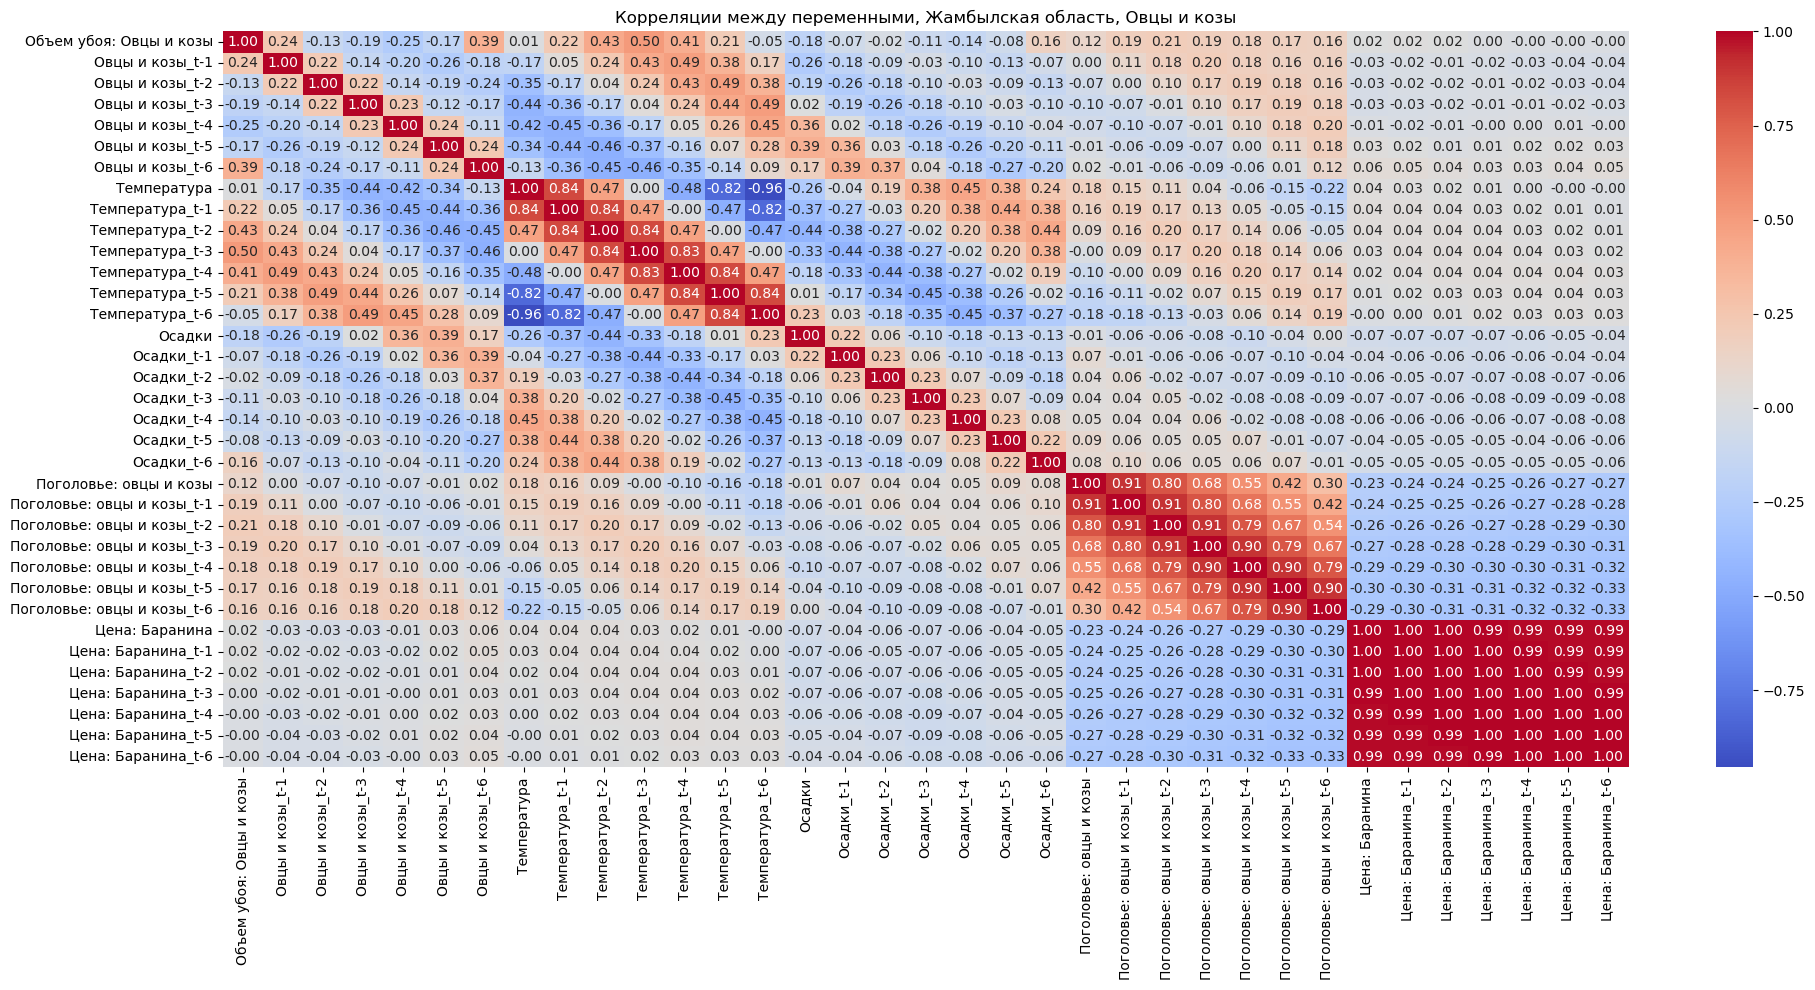

In [14]:
df_corr = df_zhambyl_full[[col for col in df_zhambyl_full.columns if col not in ["Период"]]].dropna().copy()

# 1. Correlation matrix
corr_matrix = df_corr.corr()

# 2. Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции между переменными, Жамбылская область, Овцы и козы")
plt.tight_layout()
plt.show()

*ВЫВОДЫ ПО КОРРЕЛЯЦИИ*

In [15]:
# Set your target variable
target_var = "Объем убоя: Овцы и козы"

# Get correlations with the target variable
target_corr = corr_matrix[target_var].drop(target_var)  # exclude self-correlation

# Keep only features with |correlation| >= 0.5
selected_vars = target_corr[abs(target_corr) >= 0.5].index.tolist()

print("✅ Отобранные переменные с корреляцией >= 0.5:")
print(selected_vars)

# Optionally: create new dataframe with selected variables + target
df_selected = df_zhambyl_full[['Период'] + selected_vars + [target_var]]
df_selected

✅ Отобранные переменные с корреляцией >= 0.5:
['Температура_t-3']


,Период,Температура_t-3,Объем убоя: Овцы и козы
919,2015-01-01,NaN,1814.37
920,2015-02-01,NaN,2104.12
921,2015-03-01,NaN,2251.24
922,2015-04-01,-2.306452,2227.48
923,2015-05-01,1.871429,2403.42
...,...,...,...
1034,2024-08-01,17.441935,2216.19
1035,2024-09-01,25.286667,2803.71
1036,2024-10-01,25.758065,3650.97
1037,2024-11-01,25.345161,3782.45


In [16]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()

X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Объем убоя: Овцы и козы"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Температура_t-3,1.000000
0,const,2.352295


Step-by-Step Strategy to Handle High VIFs:

Sort VIFs in descending order
Drop variables one at a time, starting with the one that has the highest VIF.

Check domain relevance
Keep variables that are theoretically important or core to your hypothesis, even if VIF is high.

Evaluate correlation matrix
If two variables have high correlation with each other, and both have high VIFs, drop the one less correlated with the target.

Recalculate VIF after each drop
After dropping one variable, recalculate all VIFs. Sometimes removing just one variable significantly reduces others.

Use stepwise selection (optional)
Automated methods like backward elimination can help drop redundant predictors based on model fit and VIF thresholds.

In [110]:
# df_selected = df_selected.drop(columns = ['Температура_t-4'])
# df_selected

In [111]:
# df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()
# X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Объем убоя: Овцы и козы"]])

# vif_data = pd.DataFrame({
#     "Variable": X_vif.columns,
#     "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
# })
# vif_data.sort_values('VIF')

In [17]:
df_selected = df_selected.dropna().copy()
df_selected

,Период,Температура_t-3,Объем убоя: Овцы и козы
922,2015-04-01,-2.306452,2227.48
923,2015-05-01,1.871429,2403.42
924,2015-06-01,3.958065,4939.28
925,2015-07-01,14.166667,2995.75
926,2015-08-01,20.106452,3008.09
...,...,...,...
1034,2024-08-01,17.441935,2216.19
1035,2024-09-01,25.286667,2803.71
1036,2024-10-01,25.758065,3650.97
1037,2024-11-01,25.345161,3782.45


### Models

#### Многофакторная регрессия

In [18]:
# Define target and features
y = df_selected["Объем убоя: Овцы и козы"]
X = df_selected.drop(columns=["Период", "Объем убоя: Овцы и козы"])

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Объем убоя: Овцы и козы   R-squared:                       0.245
Model:                                 OLS   Adj. R-squared:                  0.238
Method:                      Least Squares   F-statistic:                     37.27
Date:                     Tue, 19 Aug 2025   Prob (F-statistic):           1.43e-08
Time:                             15:46:51   Log-Likelihood:                -968.07
No. Observations:                      117   AIC:                             1940.
Df Residuals:                          115   BIC:                             1946.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [19]:
df_selected

,Период,Температура_t-3,Объем убоя: Овцы и козы
922,2015-04-01,-2.306452,2227.48
923,2015-05-01,1.871429,2403.42
924,2015-06-01,3.958065,4939.28
925,2015-07-01,14.166667,2995.75
926,2015-08-01,20.106452,3008.09
...,...,...,...
1034,2024-08-01,17.441935,2216.19
1035,2024-09-01,25.286667,2803.71
1036,2024-10-01,25.758065,3650.97
1037,2024-11-01,25.345161,3782.45


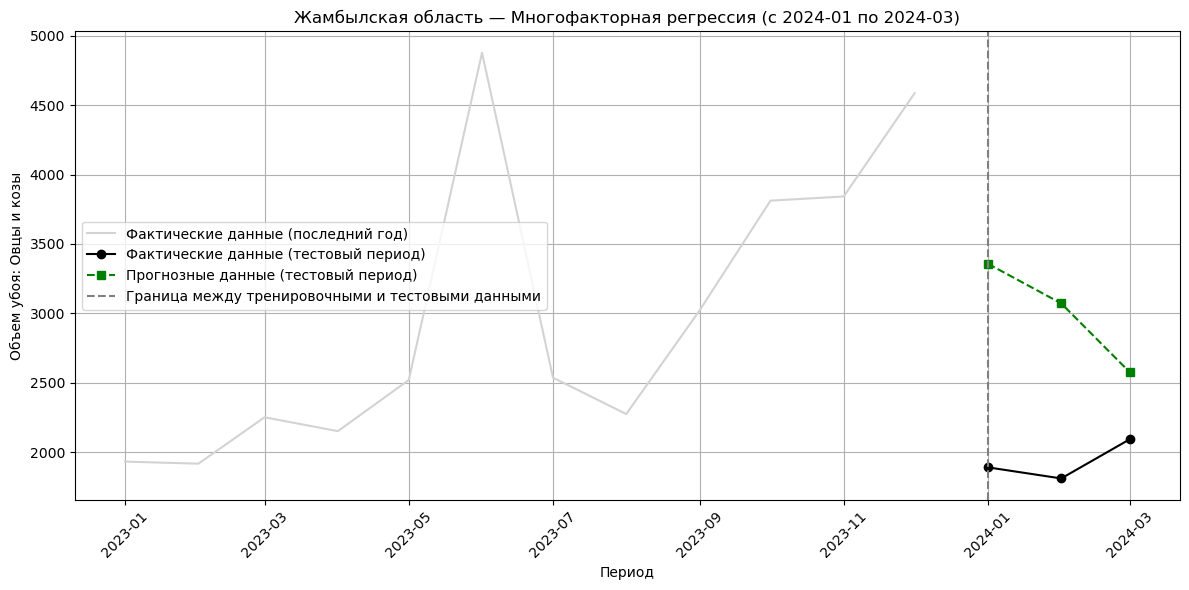

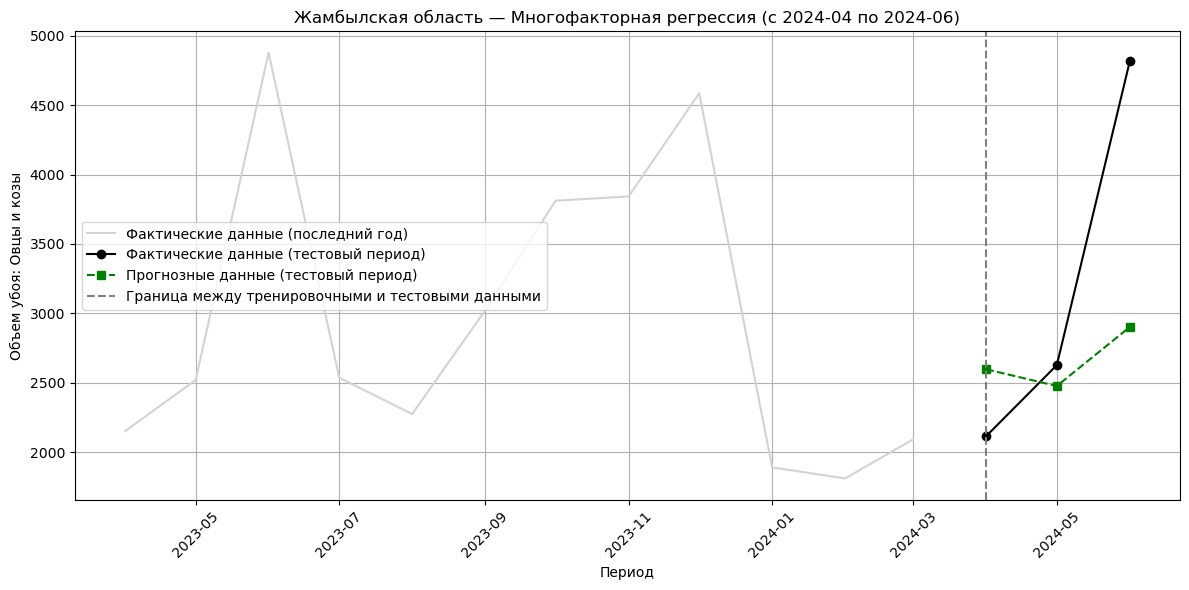

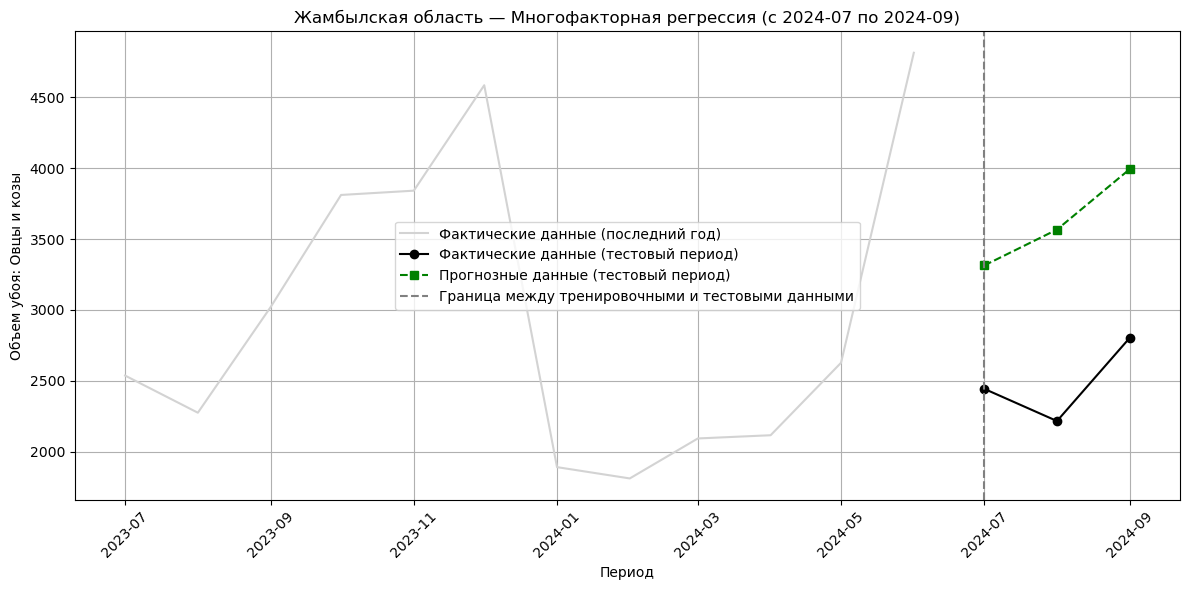

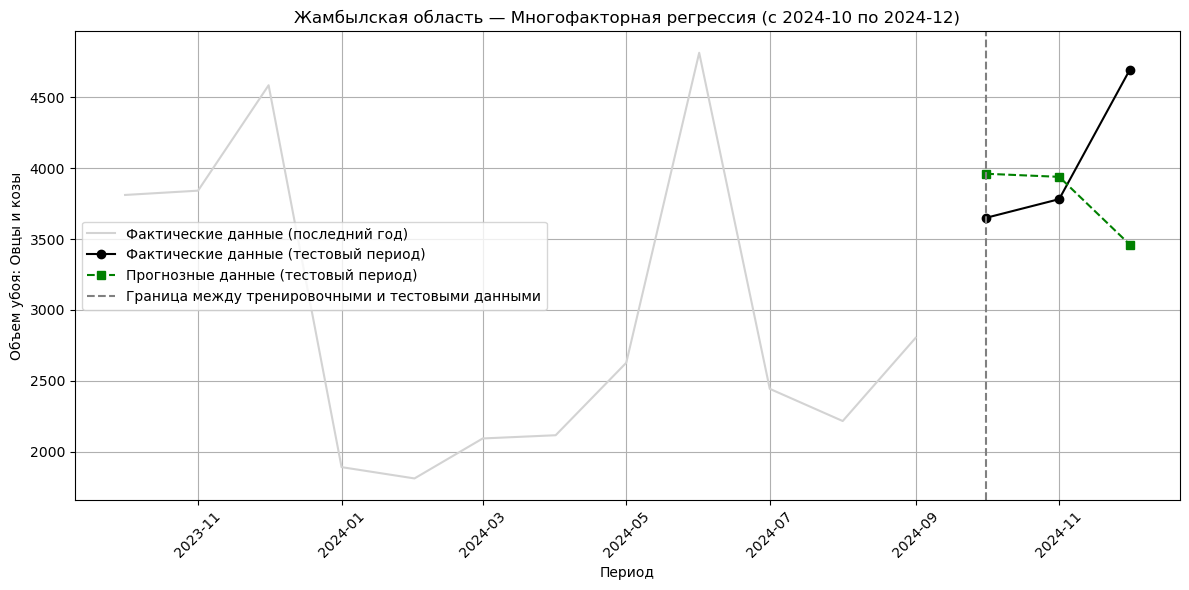

In [20]:
df = df_selected.sort_values("Период").copy()

target = "Объем убоя: Овцы и козы"
features = [col for col in df_selected.columns if col not in ['Период', 'Объем убоя: Овцы и козы']]

results = []

# Define 4 rolling test sets for 2024
start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

for start in start_dates:
    test_start = pd.to_datetime(start)
    test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {start} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Объем убоя: Овцы и козы")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03  1151.084587  1070.292742  56.760319
1  2024-04 to 2024-06  1142.764558   848.605330  22.738803
2  2024-07 to 2024-09  1155.181818  1137.782066  46.367666
3  2024-10 to 2024-12   740.097879   567.265044  12.981806
4             Average  1047.282210   905.986296  34.712148


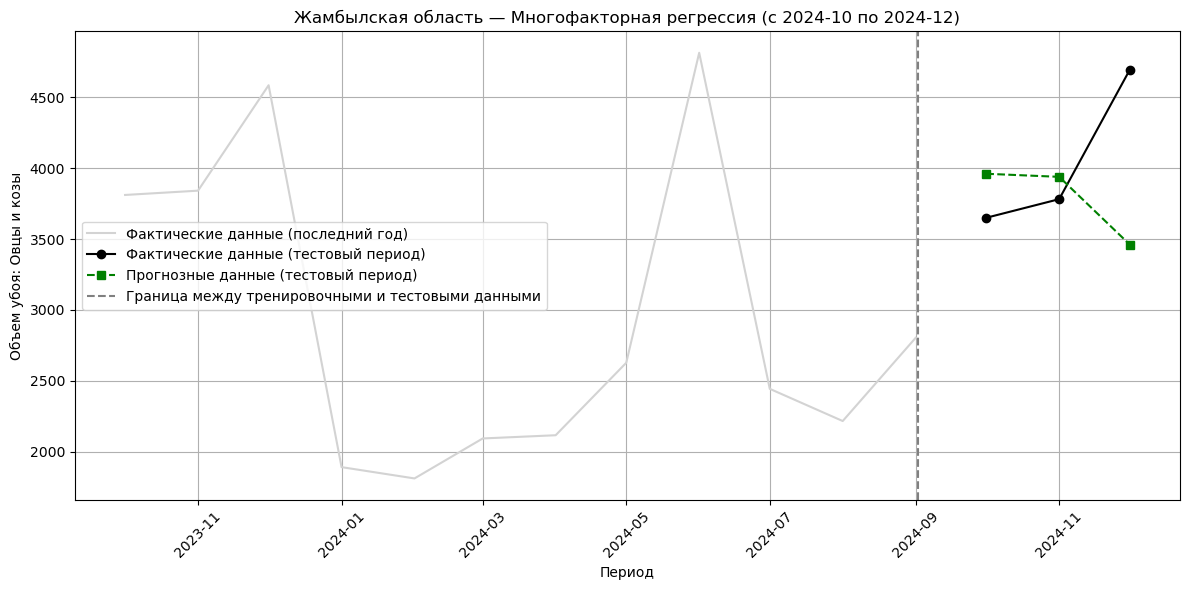

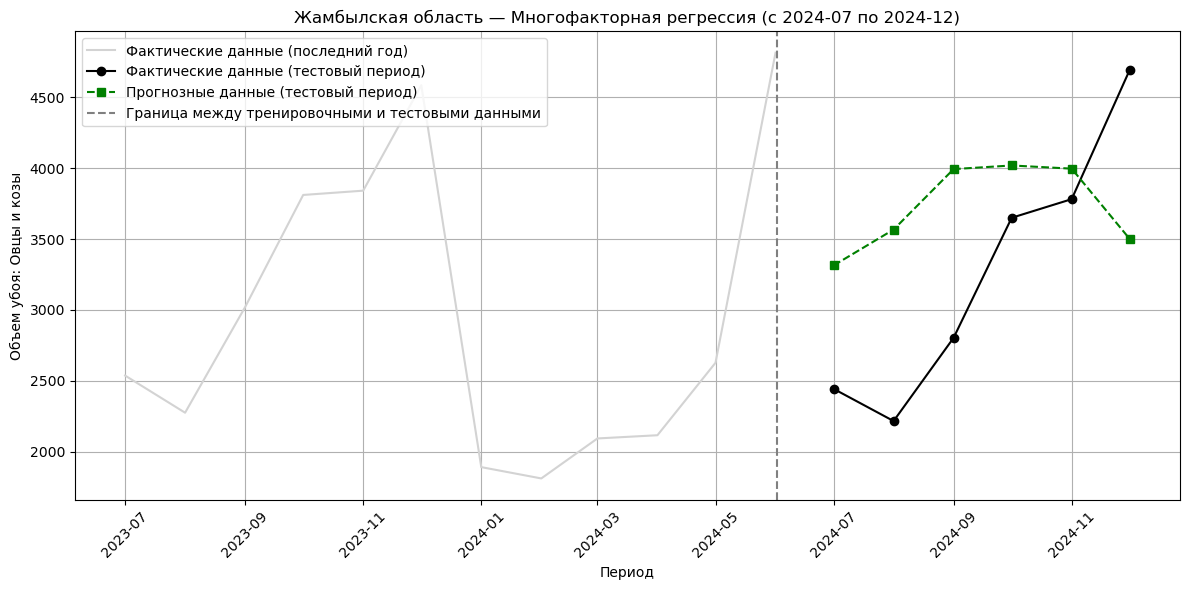

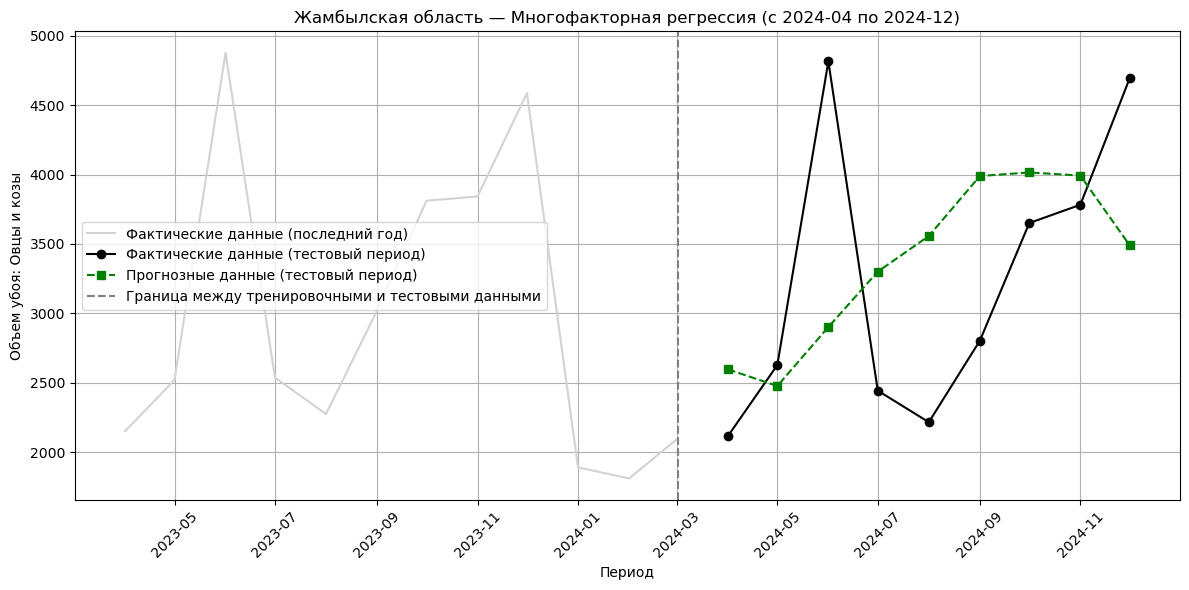

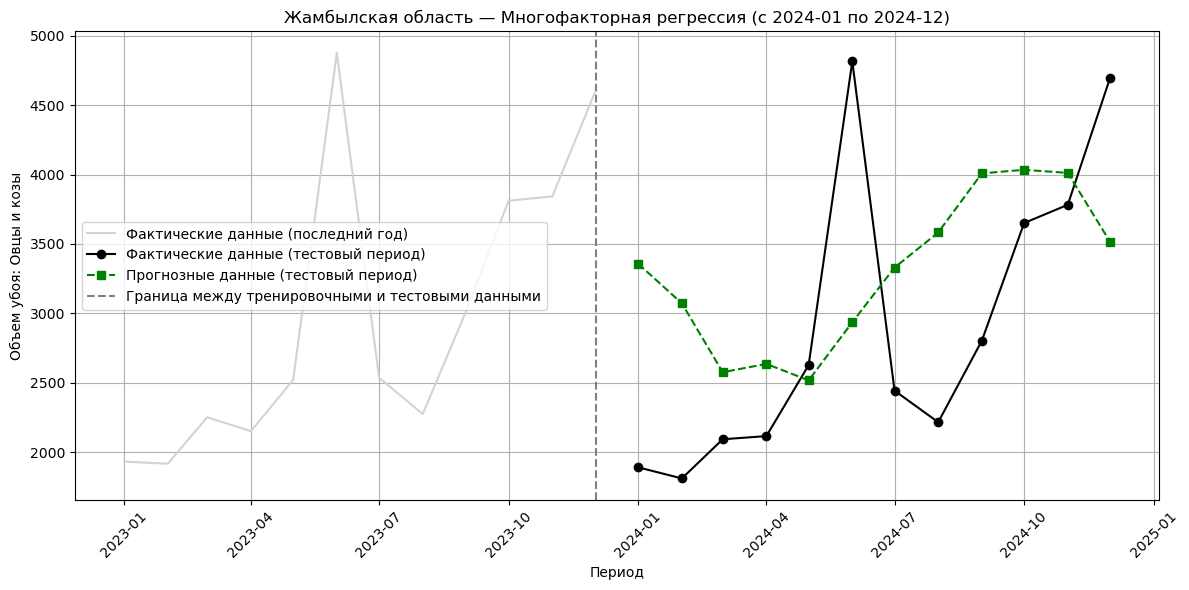

In [22]:
results = []

# Define 4 rolling test sets for 2024
horizons = [3, 6, 9, 12]

for horizon in horizons:

    test_end = pd.to_datetime("2024-12")
    test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Объем убоя: Овцы и козы")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE         MAE   MAPE (%)
0  2024-10 to 2024-12   740.097879  567.265044  12.981806
1  2024-07 to 2024-12   967.215108  865.397614  30.057875
2  2024-04 to 2024-12  1026.817176  856.780911  27.483433
3  2024-01 to 2024-12  1060.126047  914.256863  35.057745
4             Average   948.564053  800.925108  26.395215


#### SARIMA (auto-arima)

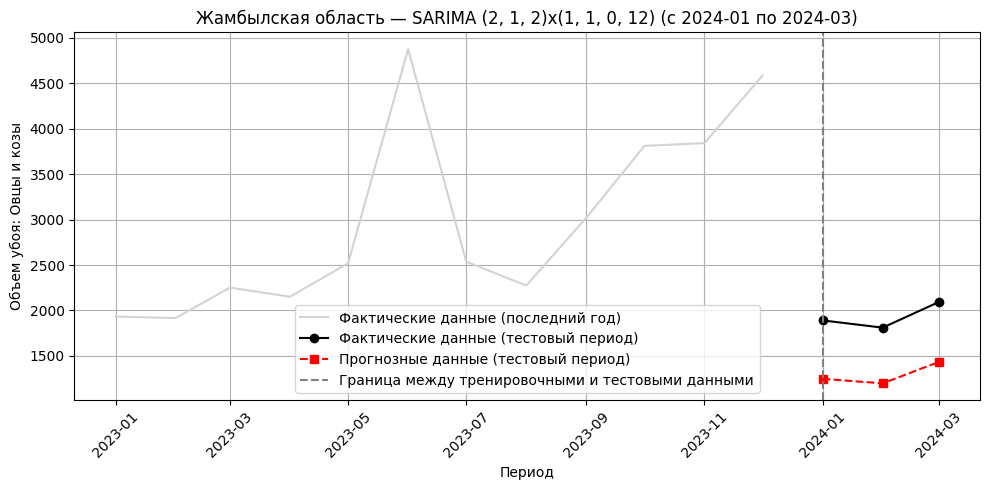

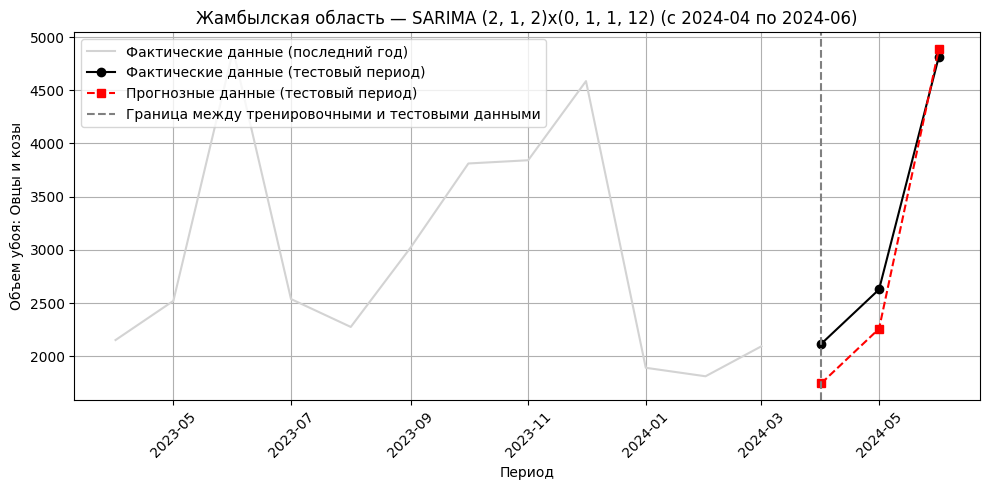

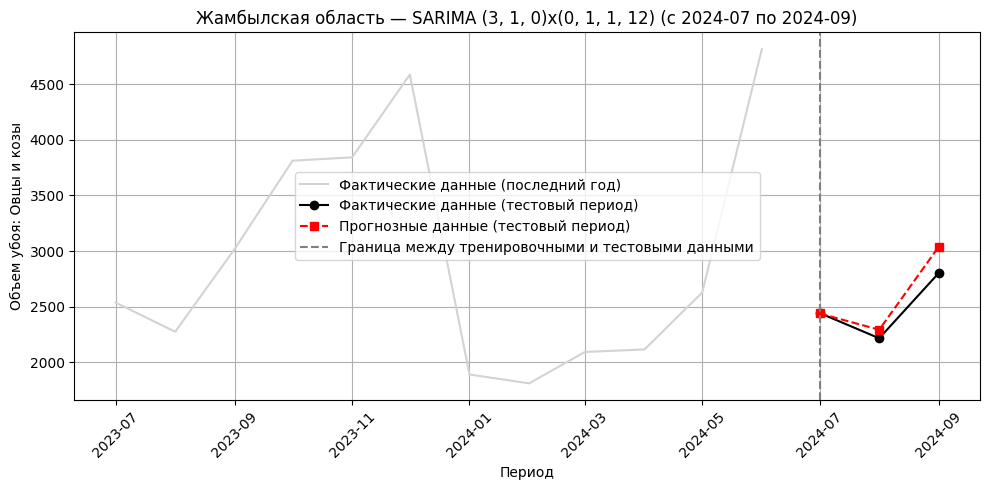

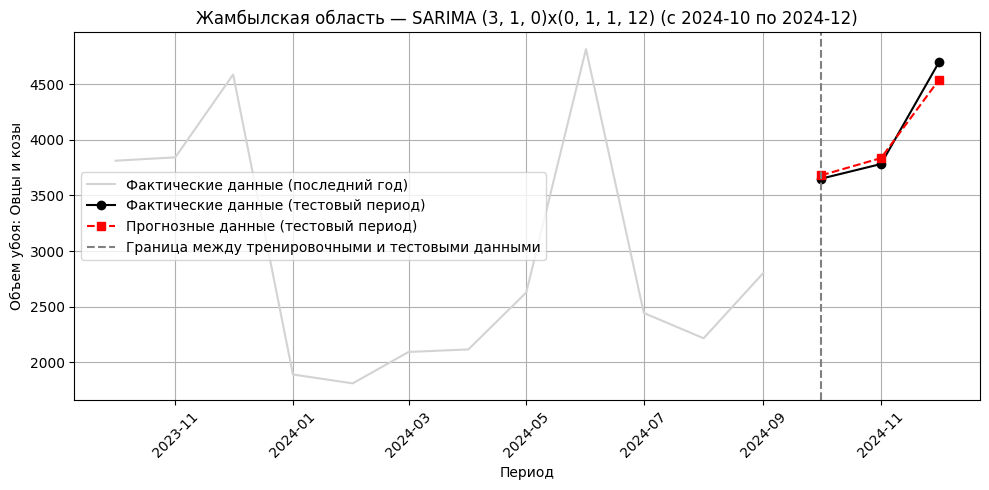

In [ ]:
# results = []

# # Определим 4 тестовых периода на 3 месяца
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Разделим данные
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=3)
#         forecast = pd.Series(forecast).reset_index(drop=True)


#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {test_start.strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()
#         # print("Zero values in y_test:", (y_test == 0).sum())


#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period        RMSE         MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  638.963176  638.671553  33.128647    (2, 1, 2)   
1  2024-04 to 2024-06  305.451546  271.157820  11.042677    (2, 1, 2)   
2  2024-07 to 2024-09  143.447385  105.644909   4.016558    (3, 1, 0)   
3  2024-10 to 2024-12   97.748617   80.317795   1.862245    (3, 1, 0)   
4             Average  296.402681  273.948019  12.512532          NaN   

  Seasonal order  
0  (1, 1, 0, 12)  
1  (0, 1, 1, 12)  
2  (0, 1, 1, 12)  
3  (0, 1, 1, 12)  
4            NaN  


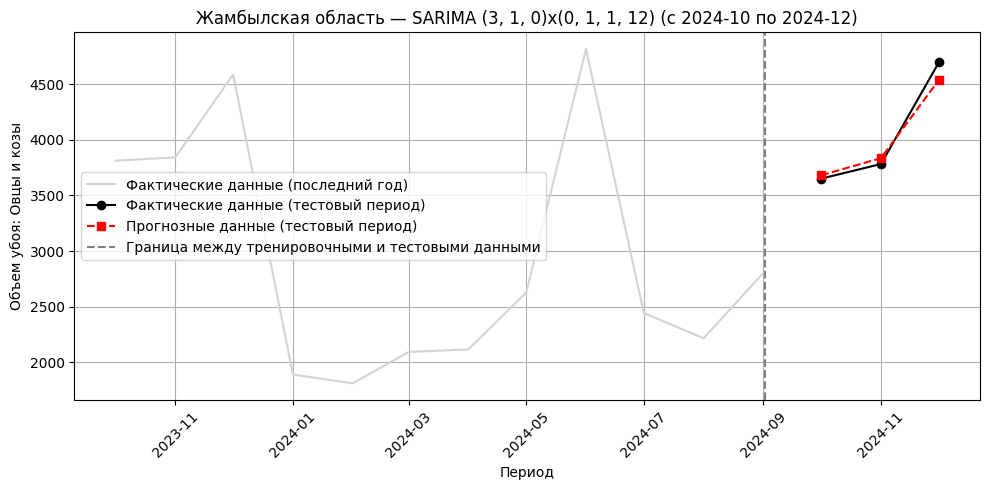

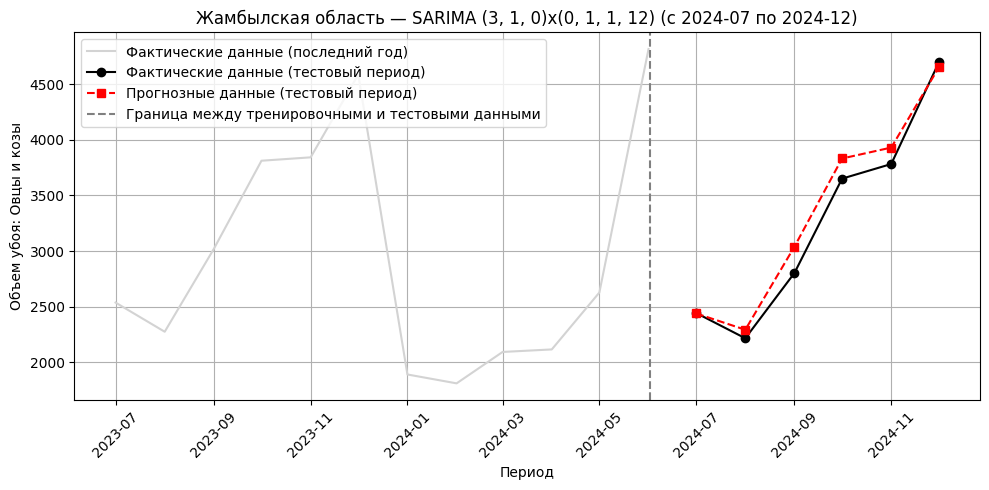

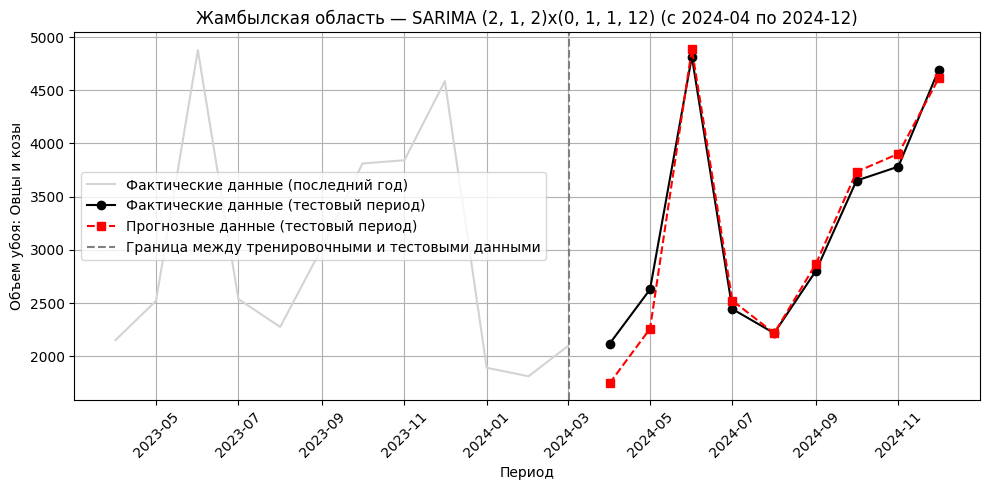

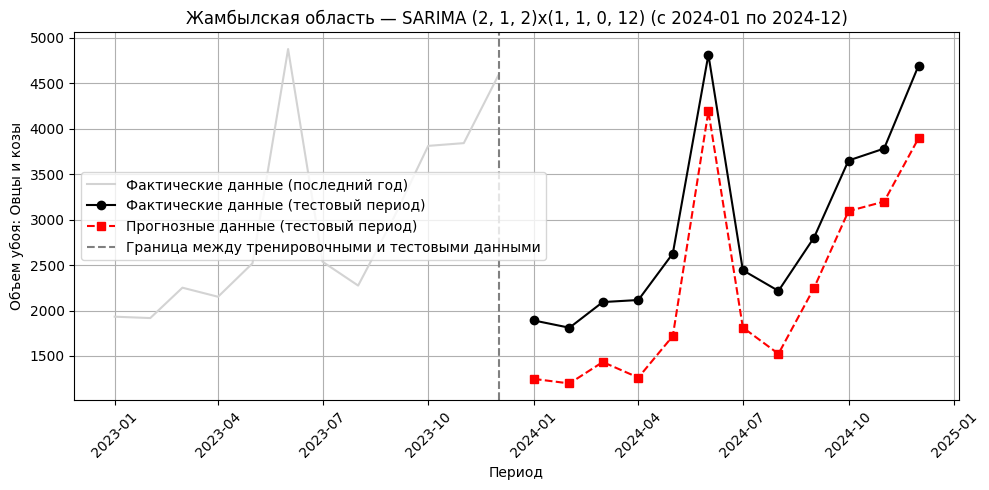

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:

#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)
    
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=horizon)
#         forecast = pd.Series(forecast).reset_index(drop=True)

#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period        RMSE         MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12   97.748617   80.317795   1.862245    (3, 1, 0)   
1  2024-07 to 2024-12  140.452963  115.104696   3.645180    (3, 1, 0)   
2  2024-04 to 2024-12  188.154169  138.201515   5.104034    (2, 1, 2)   
3  2024-01 to 2024-12  685.504776  676.406962  25.978184    (2, 1, 2)   
4             Average  277.965131  252.507742   9.147411          NaN   

  Seasonal order  
0  (0, 1, 1, 12)  
1  (0, 1, 1, 12)  
2  (0, 1, 1, 12)  
3  (1, 1, 0, 12)  
4            NaN  


#### SARIMAX

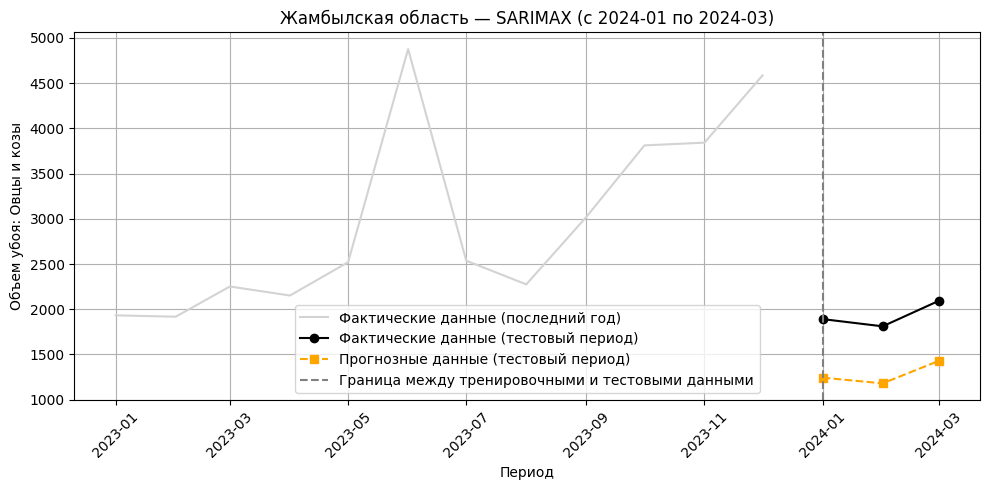

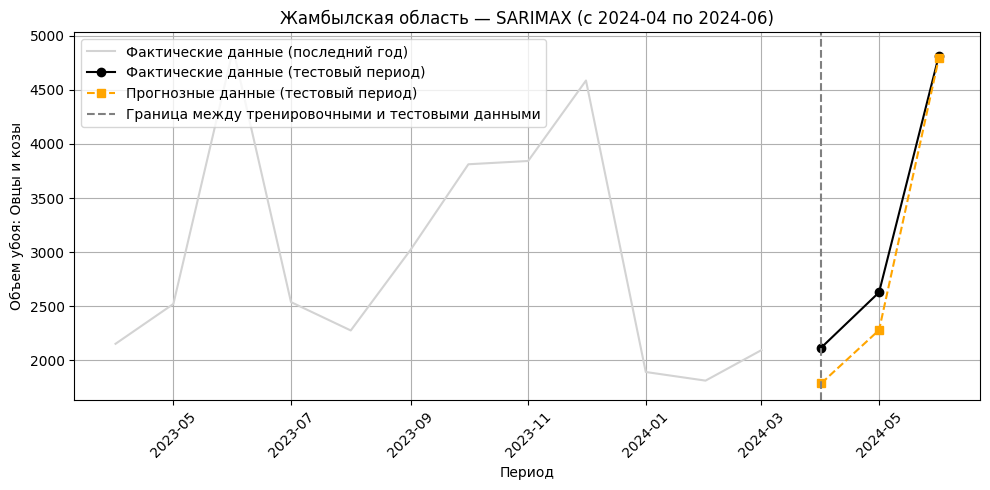

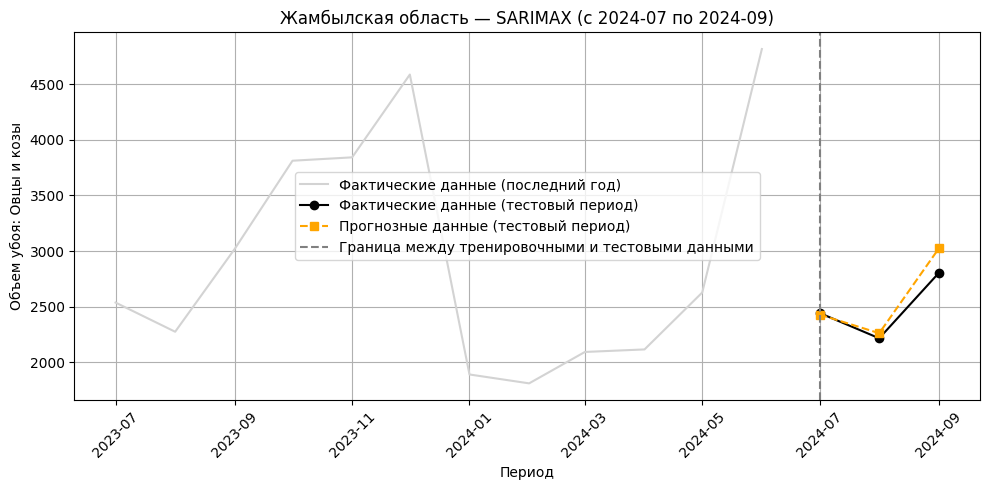

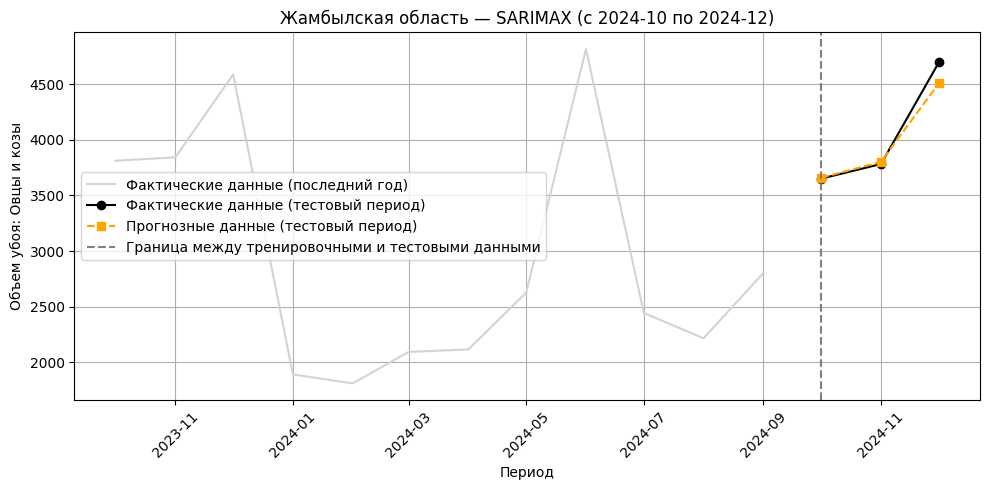

In [ ]:
# results = []

# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(3, 1, 0),
#             seasonal_order=(0, 1, 1, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=3, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {start} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)



          Test period        RMSE         MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  647.645052  647.500364  33.601688            3   
1  2024-04 to 2024-06  277.718535  234.069860   9.788593            3   
2  2024-07 to 2024-09  129.988994   93.271989   3.495380            3   
3  2024-10 to 2024-12  109.184878   72.108319   1.587038            3   
4             Average  291.134365  261.737633  12.118175                

  Seasonal order  
0              0  
1              0  
2              0  
3              0  
4                 


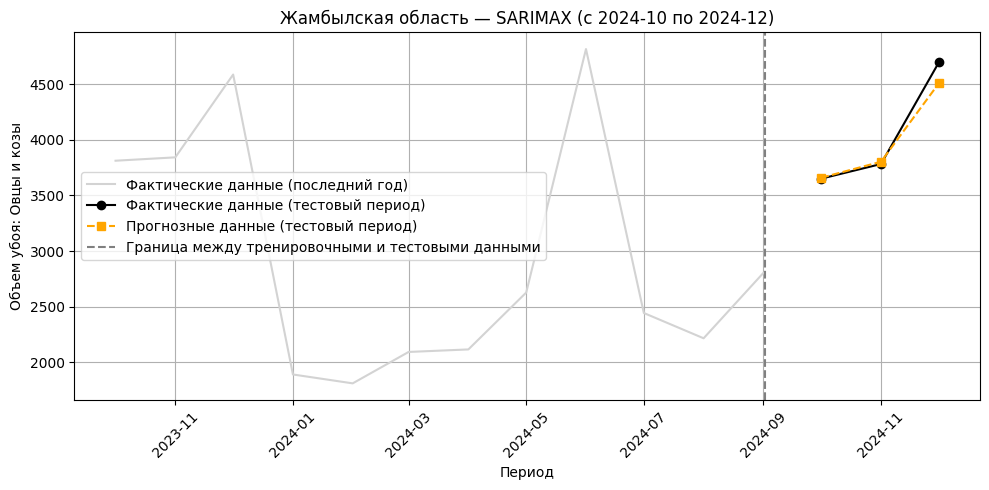

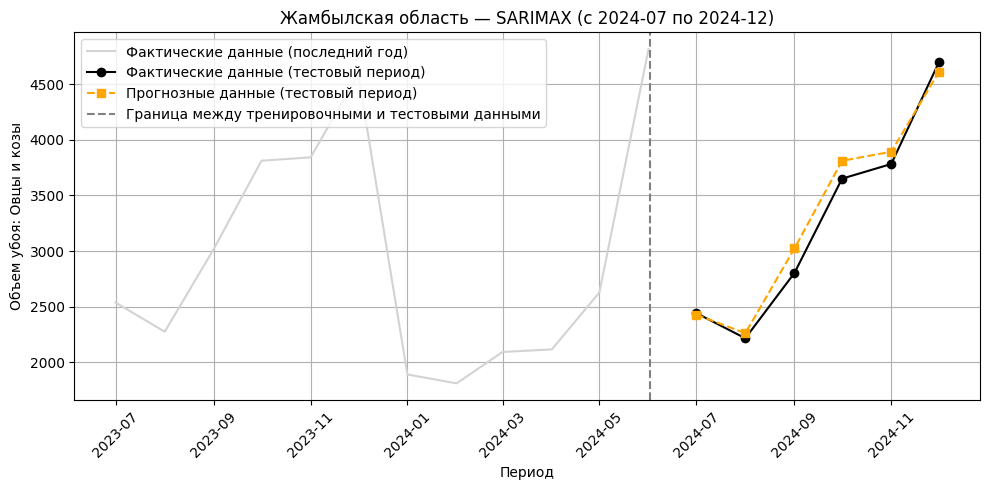

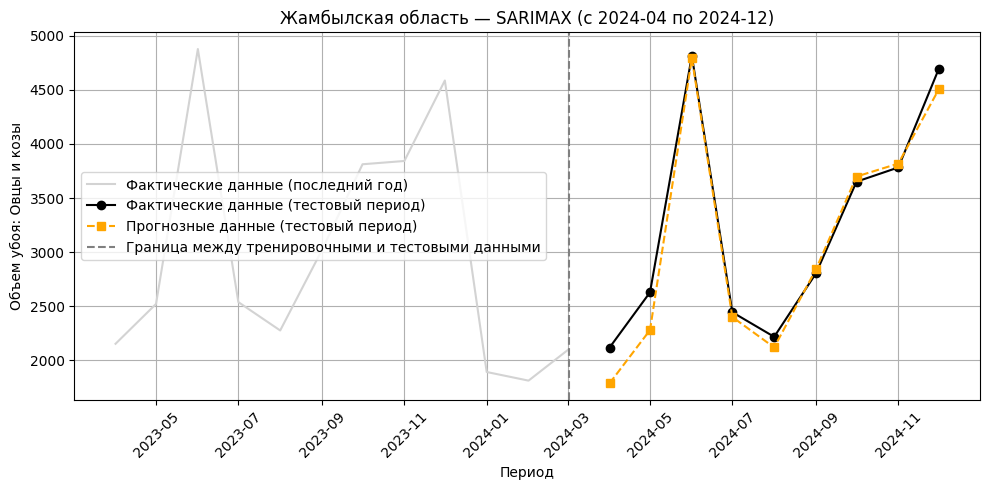

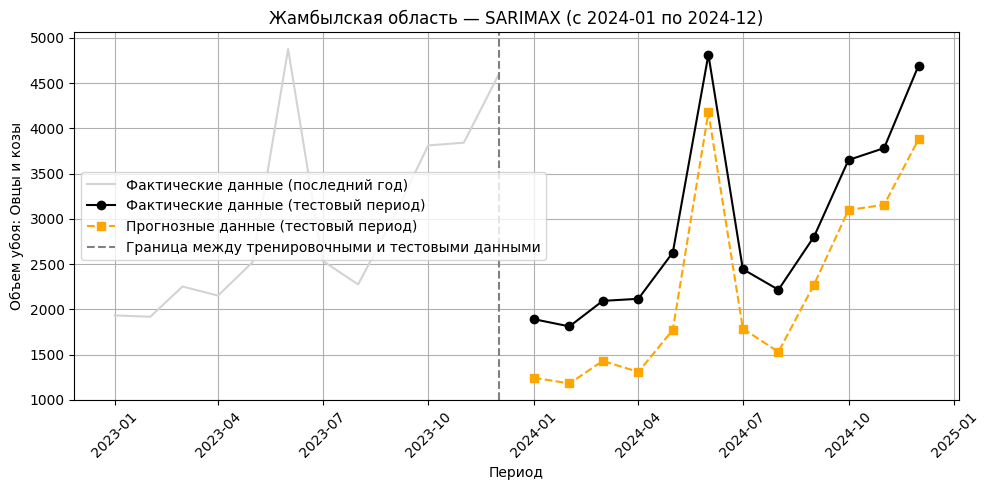

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:
#     # test_start = pd.to_datetime(start)
#     # test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(3, 1, 0),
#             seasonal_order=(0, 1, 1, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=horizon, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)

          Test period        RMSE         MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  109.184878   72.108319   1.587038            3   
1  2024-07 to 2024-12  126.529448  106.162083   3.272647            3   
2  2024-04 to 2024-12  177.585738  128.377673   4.804919            3   
3  2024-01 to 2024-12  683.259387  676.321417  25.895673            3   
4             Average  274.139863  245.742373   8.890069                

  Seasonal order  
0              0  
1              0  
2              0  
3              0  
4                 


#### Prophet

16:51:57 - cmdstanpy - INFO - Chain [1] start processing
16:51:57 - cmdstanpy - INFO - Chain [1] done processing


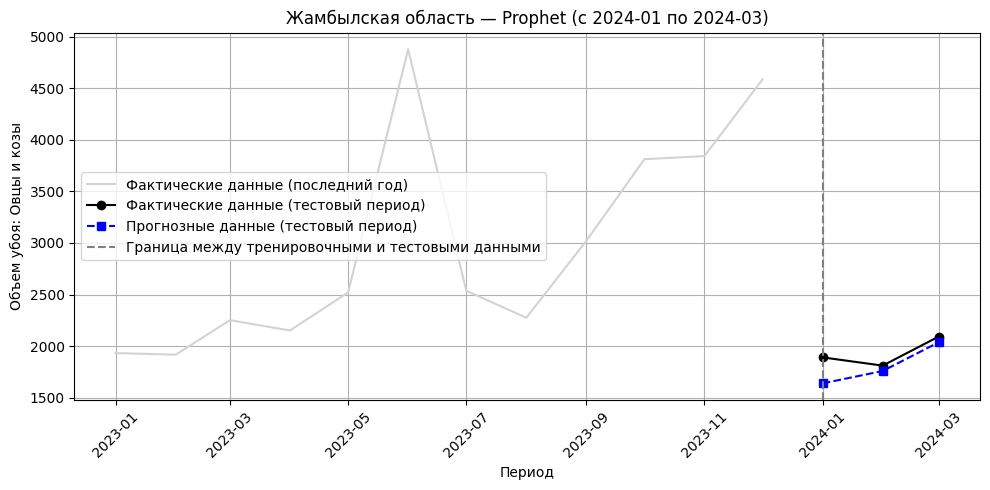

16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing


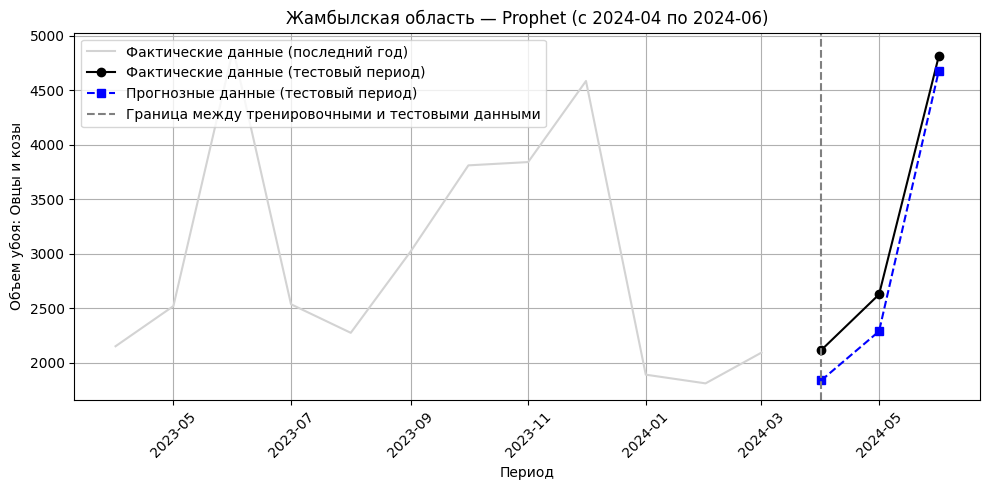

16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing


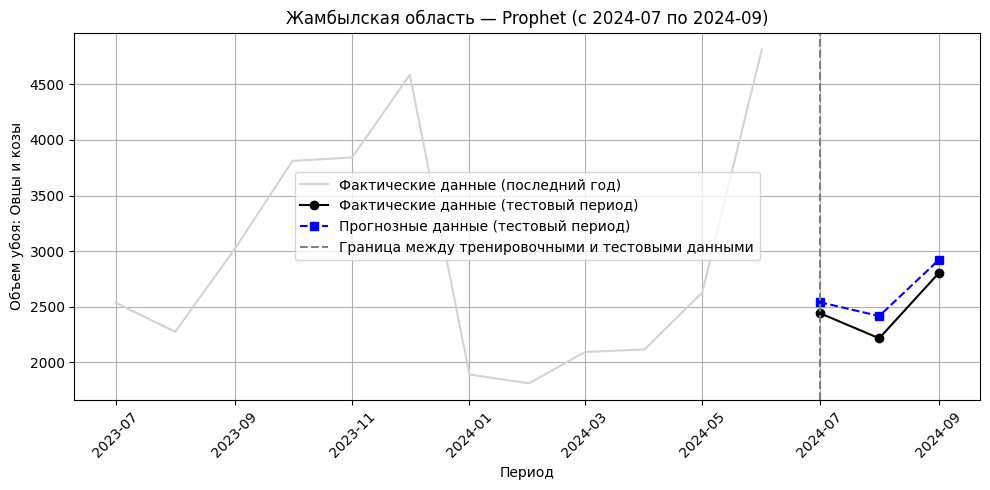

16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing


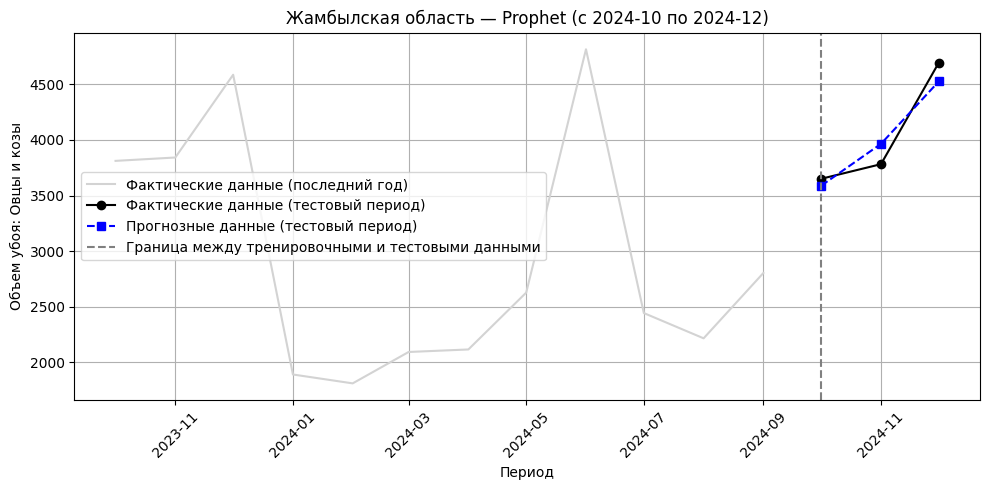

In [ ]:
# results = []

# # Define 4 test periods
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Train/test split
#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Initialize Prophet
#     model = Prophet()

#     # Optional: add regressors
#     # model.add_regressor("Температура_t-1")
#     # prophet_train["Температура_t-1"] = train_df["Температура_t-1"].values
#     # prophet_test["Температура_t-1"] = test_df["Температура_t-1"].values

#     # Fit
#     model.fit(prophet_train)

#     # Create future dataframe
#     future = model.make_future_dataframe(periods=3, freq="M")
#     forecast = model.predict(future)
# # forecast
# # prophet_test

#     # Extract forecast for test period only
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {start} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Объем убоя: Овцы и козы")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()



In [ ]:
# results_df = pd.DataFrame(results)
# avg = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg])], ignore_index=True)
# print(results_df)

          Test period        RMSE         MAE  MAPE (%)
0  2024-01 to 2024-03  151.888956  119.811843  6.282508
1  2024-04 to 2024-06  264.312480  249.986138  9.595496
2  2024-07 to 2024-09  145.786763  138.955259  5.759640
3  2024-10 to 2024-12  147.851203  137.707858  3.371670
4             Average  177.459850  161.615274  6.252328


16:52:00 - cmdstanpy - INFO - Chain [1] start processing
16:52:00 - cmdstanpy - INFO - Chain [1] done processing


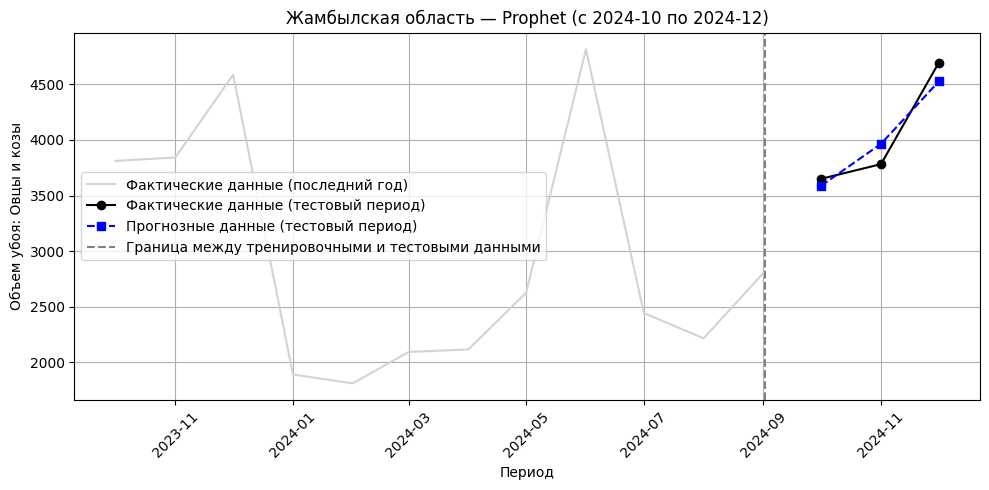

16:52:00 - cmdstanpy - INFO - Chain [1] start processing
16:52:00 - cmdstanpy - INFO - Chain [1] done processing


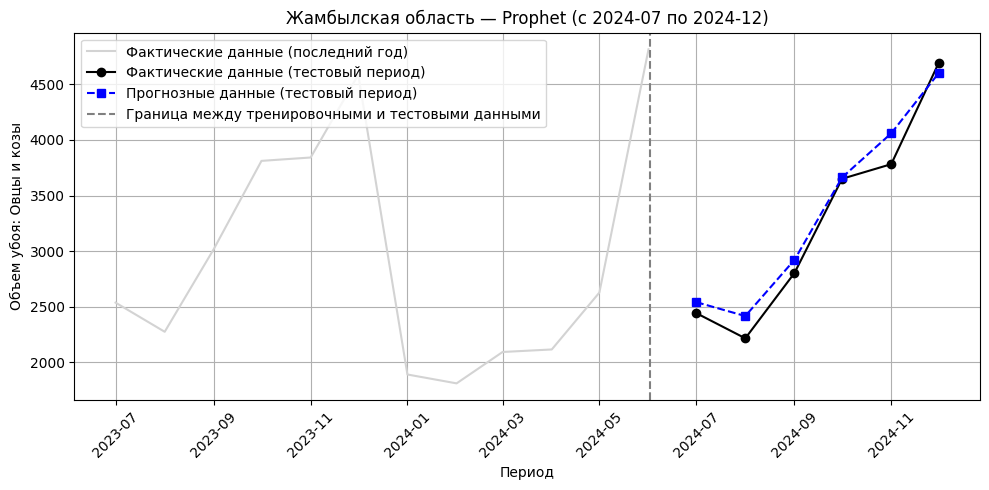

16:52:01 - cmdstanpy - INFO - Chain [1] start processing
16:52:01 - cmdstanpy - INFO - Chain [1] done processing


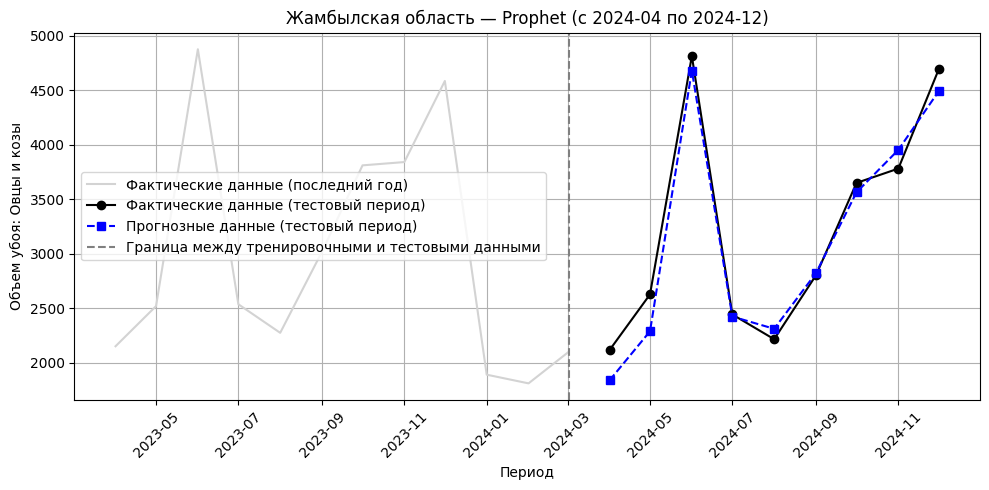

16:52:02 - cmdstanpy - INFO - Chain [1] start processing
16:52:02 - cmdstanpy - INFO - Chain [1] done processing


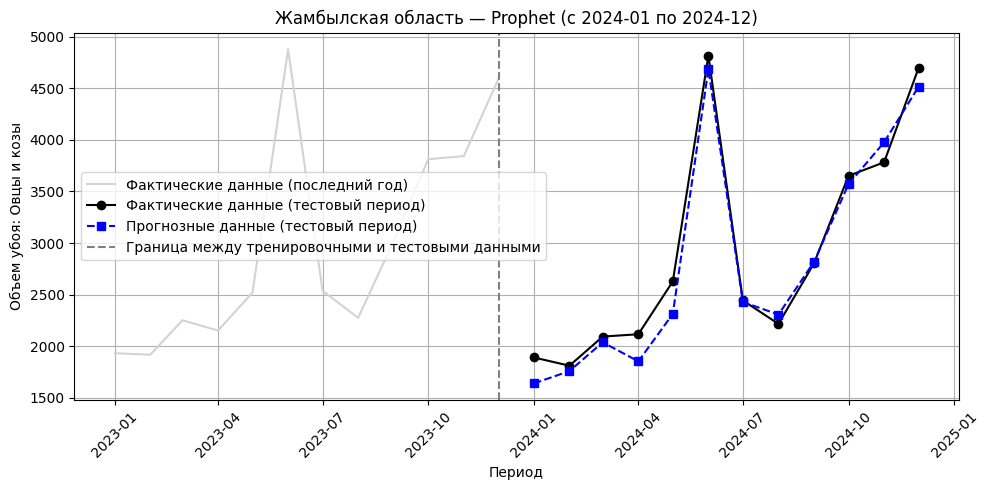

In [ ]:
# horizons = [3, 6, 9, 12]
# results = []

# for horizon in horizons:

#     # Define train/test split
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Fit Prophet
#     model = Prophet()
#     model.fit(prophet_train)

#     # Forecast
#     future = model.make_future_dataframe(periods=horizon, freq="M")
#     forecast = model.predict(future)

#     # Extract matching forecasted months
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluation
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Объем убоя: Овцы и козы")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()




In [ ]:
# # Summary table
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)

          Test period        RMSE         MAE  MAPE (%)
0  2024-10 to 2024-12  147.851203  137.707858  3.371670
1  2024-07 to 2024-12  157.780107  133.061792  4.483674
2  2024-04 to 2024-12  181.599071  149.253419  5.085109
3  2024-01 to 2024-12  168.270710  136.821480  5.193500
4                 NaN  163.875273  139.211137  4.533488


strength of correlation:
https://link.springer.com/article/10.1057/jt.2009.5#
https://resources.nu.edu/statsresources/correlation